**Step 1 : Import Libraries**

In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

**Step 2 :Load the dataset**

In [5]:
df = pd.read_csv("Dataset .csv")

In [6]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


**Step 3 : Check data set**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [8]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

**Step 4 : Remove Missing values**

In [9]:
df = df.dropna()

**Step 5 : Keep only the First Cuisine**

In [10]:

df["Cuisines"] = df["Cuisines"].str.split(",").str[0].str.strip()

**Step 6 : Encode Categorical Columns**

In [11]:
le = LabelEncoder()
df["Cuisines"]= le.fit_transform(df["Cuisines"])
df["City"] =le.fit_transform(df["City"].astype(str))

In [12]:
df["Cuisines"]
df["City"]

0        73
1        73
2        75
3        75
4        75
       ... 
9546    139
9547    139
9548    139
9549    139
9550    139
Name: City, Length: 9542, dtype: int64

**Step 7 : Select Features (x) and Target (y)**

In [13]:
x = df[[
    "Country Code",
    "City",
    "Longitude",
    "Latitude",
    "Average Cost for two",
    "Price range",
    "Votes",
    "Aggregate rating"]]

y = df["Cuisines"]
    

**Step 8 : Split the dataset**

In [14]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

**Step 9 : Create Random Forest Model**

In [15]:
from sklearn.ensemble import RandomForestClassifier

model= RandomForestClassifier(n_estimators=200,random_state=42)

**Step  10: Train the Model**

In [16]:
model.fit(x_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Step 11 : Make Predictions**

In [17]:
y_pred = model.predict(x_test)

**Step 12 : Calculate Accuracy**

In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:" ,accuracy)


Accuracy: 0.3101100052383447


**Step 13 : Classification Report**

In [19]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           2       0.24      0.27      0.26        55
           3       0.00      0.00      0.00         1
           6       0.25      0.12      0.16        17
           7       0.00      0.00      0.00         1
          10       0.00      0.00      0.00         0
          11       0.00      0.00      0.00         5
          12       0.20      0.17      0.18       109
          13       0.00      0.00      0.00         6
          14       0.00      0.00      0.00         4
          15       0.00      0.00      0.00        13
          17       0.40      0.09      0.15        22
          18       0.33      0.50      0.40         4
          19       0.00      0.00      0.00         3
          20       0.00      0.00      0.00         4
          21       0.00      0.00      0.00        31
          22       0.00      0.00      0.00         1
          23       0.20    

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-pa

**Step 14 : Confusion Matrix**

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)
print(cm)

[[ 0  0  0 ...  0  0  0]
 [ 0 15  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 ...
 [ 0  0  0 ...  0  0  0]
 [ 0  1  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]]


**Step 15 : Feature Importance**

In [21]:
importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": model.feature_importances_})

importance = importance.sort_values(by="Importance",ascending=False)
print(importance)

                Feature  Importance
2             Longitude    0.238973
3              Latitude    0.238955
6                 Votes    0.182528
4  Average Cost for two    0.132437
7      Aggregate rating    0.122525
1                  City    0.049543
5           Price range    0.023224
0          Country Code    0.011816


**Step 16 : Plot Feature Importance**

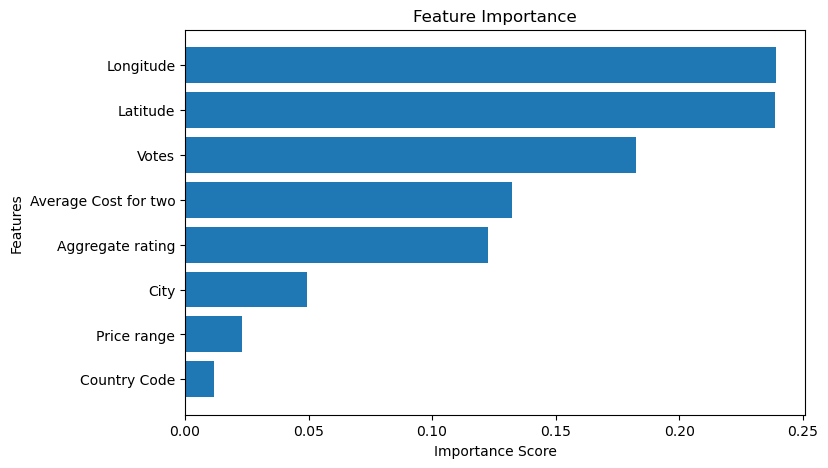

In [22]:
import matplotlib.pyplot as plt
importance = importance.sort_values(by= "Importance",ascending=True)

plt.figure(figsize=(8,5))
plt.barh(importance["Feature"],
importance["Importance"])

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

**Step 17 : Conclusion**

A Random Forest Classifier was trained to predict restaurant cuisines.The model achieves an accuracy of approximately 31.55%. Feature importance 
analysis showed that Longitude and Latitude were the most influential features,followed by Votes,Average cost for Two,and Aggregate Rating. These 
features contributed the most to the model's predictions.